# PoC 2d: Hypothesis-First Foresight

Invert the poc2c pipeline: instead of extracting what the corpus contains, generate disruption hypotheses and then search for evidence to validate or falsify them.

**Domain:** Regulatory Spectrum Monitoring (R&S core business)

**Pipeline:** LLM Hypotheses (5 frameworks) → OpenAlex Evidence Search → Faithfulness Check → Categorize (Validated / Speculative / Falsified) → Surprise Assessment → Audit Trail

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(".."))

from dotenv import load_dotenv
load_dotenv("../.env")

from openai import AzureOpenAI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path

from src.models import (
    Hypothesis, HypothesisBatch, HypothesisVerdict,
    FaithfulnessResult, SurpriseAssessment,
)

client = AzureOpenAI(
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    api_version=os.environ["AZURE_OPENAI_API_VERSION"],
)
MODEL = os.environ.get("AZURE_OPENAI_DEPLOYMENT", "gpt-4o")

print(f"LLM: {MODEL}")

LLM: gpt-4o


## 1. Domain Context: Regulatory Spectrum Monitoring

In [2]:
DOMAIN_CONTEXT = """DOMAIN: Regulatory Spectrum Monitoring

Rohde & Schwarz (R&S) is a leading provider of spectrum monitoring solutions for national
regulatory authorities and defense agencies worldwide. Their portfolio includes:

- Fixed monitoring stations and nationwide monitoring networks
- Mobile and portable spectrum monitoring receivers
- Direction finding and geolocation systems (DF/TDOA)
- Automated signal identification and classification
- Spectrum management databases and software platforms

Current status quo:
- Hardware-centric business: high-performance RF receivers, antennas, DF arrays
- Customers: national regulators (BNetzA, FCC, Ofcom, etc.), military/intelligence agencies
- Market drivers: growing spectrum demand (5G/6G, IoT, satellite), interference management
- Known investments: AI-assisted signal classification, wider bandwidth receivers, cloud-based monitoring

What R&S already tracks (known trends):
- 5G/6G spectrum allocation and testing
- Dynamic Spectrum Access / CBRS-style sharing
- Satellite mega-constellations (Starlink, etc.) and spectrum coordination
- AI/ML for automated signal recognition
- Software-defined receivers and virtualized monitoring
- Electronic warfare / SIGINT modernization
"""

print(DOMAIN_CONTEXT)

DOMAIN: Regulatory Spectrum Monitoring

Rohde & Schwarz (R&S) is a leading provider of spectrum monitoring solutions for national
regulatory authorities and defense agencies worldwide. Their portfolio includes:

- Fixed monitoring stations and nationwide monitoring networks
- Mobile and portable spectrum monitoring receivers
- Direction finding and geolocation systems (DF/TDOA)
- Automated signal identification and classification
- Spectrum management databases and software platforms

Current status quo:
- Hardware-centric business: high-performance RF receivers, antennas, DF arrays
- Customers: national regulators (BNetzA, FCC, Ofcom, etc.), military/intelligence agencies
- Market drivers: growing spectrum demand (5G/6G, IoT, satellite), interference management
- Known investments: AI-assisted signal classification, wider bandwidth receivers, cloud-based monitoring

What R&S already tracks (known trends):
- 5G/6G spectrum allocation and testing
- Dynamic Spectrum Access / CBRS-style s

## 2. Hypothesis Generation (5 Disruption Frameworks)

One LLM call per framework — 6 hypotheses each = 30 total. Temperature 0.7 for creative exploration.

In [3]:
FRAMEWORKS = {
    "Christensen Disruption": (
        "Identify technologies that are currently 'good enough' and cheap, coming from below "
        "to undermine R&S's high-performance spectrum monitoring hardware. Think: what if a "
        "$50 SDR dongle network replaces a $500k monitoring station? What low-end approaches "
        "from adjacent fields could become 'good enough' for regulatory monitoring?"
    ),
    "Adjacent Possible": (
        "Identify combinations of existing technologies that are JUST NOW becoming feasible "
        "and could create entirely new approaches to spectrum monitoring. Think: what happens "
        "when LEO satellites + edge AI + crowdsourced sensors converge? What new capabilities "
        "emerge from combining mature technologies in novel ways?"
    ),
    "Regulatory Shock": (
        "Identify policy or regulatory changes that could fundamentally restructure how "
        "spectrum is monitored, allocated, or enforced. Think: what if spectrum becomes "
        "a real-time market? What if monitoring obligations shift from regulators to operators? "
        "What geopolitical shifts could fragment global spectrum governance?"
    ),
    "Platform Shift": (
        "Identify shifts in where value is created in the spectrum monitoring chain. Think: "
        "what if the value moves from receivers to analytics platforms? What if monitoring "
        "becomes a cloud service instead of a hardware deployment? Who could become the "
        "new platform owner that R&S depends on or competes with?"
    ),
    "Convergence": (
        "Identify industries or domains that are merging with spectrum monitoring in unexpected "
        "ways. Think: cybersecurity + spectrum = RF threat detection? Autonomous vehicles + "
        "spectrum = mobile sensing platforms? Climate monitoring + spectrum = dual-use infrastructure? "
        "What cross-industry convergences create new competitors or opportunities?"
    ),
}

HYPOTHESIS_SYSTEM = f"""You are a strategic foresight analyst specializing in technology disruption.
Your task: generate non-obvious, specific disruption hypotheses for a given domain using a
specific disruption framework.

{DOMAIN_CONTEXT}

RULES:
- Each hypothesis must be SPECIFIC and FALSIFIABLE, not vague ("AI will change things")
- Focus on what R&S is NOT already tracking (see known trends above)
- Think 5-10 year horizon
- For each hypothesis, generate 2-4 concrete search queries that could find supporting evidence
- Prefer cross-domain, second-order, and non-obvious angles
- Number hypotheses sequentially within the batch (the id will be set by the framework prefix)
"""

all_hypotheses: list[Hypothesis] = []

for fw_name, fw_prompt in FRAMEWORKS.items():
    prefix = fw_name[:3].upper()  # CHR, ADJ, REG, PLA, CON

    response = client.beta.chat.completions.parse(
        model=MODEL,
        messages=[
            {"role": "system", "content": HYPOTHESIS_SYSTEM},
            {"role": "user", "content": (
                f"Framework: {fw_name}\n\n"
                f"{fw_prompt}\n\n"
                f"Generate exactly 6 disruption hypotheses. Use IDs {prefix}-01 through {prefix}-06."
            )},
        ],
        response_format=HypothesisBatch,
        temperature=0.7,
    )

    batch = response.choices[0].message.parsed.hypotheses
    all_hypotheses.extend(batch)
    print(f"\n{fw_name} ({len(batch)} hypotheses):")
    for h in batch:
        print(f"  {h.id}: {h.hypothesis[:100]}...")
    time.sleep(1)

print(f"\nTotal: {len(all_hypotheses)} hypotheses across {len(FRAMEWORKS)} frameworks")


Christensen Disruption (6 hypotheses):
  CHR-01: A distributed network of low-cost software-defined radios (SDRs) could become 'good enough' for basi...
  CHR-02: Crowdsourced spectrum monitoring using mobile devices equipped with RF sensors could provide a cost-...
  CHR-03: Advancements in edge AI for signal processing could enable low-cost devices to perform sophisticated...
  CHR-04: Open-source spectrum management platforms, combined with low-cost hardware, could disrupt proprietar...
  CHR-05: The increasing prevalence of satellite-based RF monitoring could reduce the reliance on ground-based...
  CHR-06: Machine learning algorithms developed for adjacent fields like image recognition may find new applic...



Adjacent Possible (6 hypotheses):
  ADJ-01: The convergence of LEO satellite networks, edge computing, and federated AI training will enable rea...
  ADJ-02: Crowdsourced spectrum sensors combined with blockchain can create secure and decentralized spectrum ...
  ADJ-03: Integration of UAV-mounted sensors with autonomous navigation can establish flexible, on-demand spec...
  ADJ-04: Combining smart city IoT deployments with integrated spectrum monitoring modules will provide contin...
  ADJ-05: Miniaturized, low-cost spectrum sensors embedded in consumer electronics could enable pervasive spec...
  ADJ-06: Advanced quantum sensors for RF applications will allow unprecedented sensitivity and resolution in ...



Regulatory Shock (6 hypotheses):
  REG-01: A shift towards a real-time spectrum marketplace, where spectrum access is dynamically auctioned in ...
  REG-02: International fragmentation in spectrum governance due to geopolitical tensions could result in dive...
  REG-03: Mandatory decentralization of spectrum monitoring tasks to private operators might be enforced to di...
  REG-04: Introduction of environmental impact regulations on spectrum usage could force changes in transmitte...
  REG-05: A global treaty mandating standardized spectrum monitoring protocols and equipment could emerge to f...
  REG-06: Emergence of citizen-led spectrum observation networks, driven by public access to RF monitoring too...



Platform Shift (6 hypotheses):
  PLA-01: Cloud-native spectrum monitoring platforms become the dominant form, with value shifting from hardwa...
  PLA-02: A major cloud provider like AWS or Azure enters the spectrum monitoring space, leveraging their exis...
  PLA-03: Open-source software for spectrum monitoring gains traction, shifting control away from proprietary ...
  PLA-04: Satellite-based spectrum monitoring becomes commercially viable, reducing reliance on ground-based i...
  PLA-05: AI-driven autonomous spectrum monitoring platforms emerge as independent entities, reducing the need...
  PLA-06: Governments mandate that spectrum monitoring data be shared on centralized public platforms, diminis...



Convergence (6 hypotheses):
  CON-01: The convergence of climate monitoring and spectrum monitoring technologies could lead to the develop...
  CON-02: Autonomous vehicle platforms could integrate advanced spectrum monitoring to enhance vehicle-to-vehi...
  CON-03: Cybersecurity platforms may converge with spectrum monitoring to create solutions that detect RF-bas...
  CON-04: Healthcare monitoring devices could leverage spectrum monitoring technologies to ensure reliable ope...
  CON-05: Smart city infrastructures could increasingly integrate spectrum monitoring to manage the RF environ...
  CON-06: The entertainment industry could adopt spectrum monitoring to ensure the reliable operation of wirel...



Total: 30 hypotheses across 5 frameworks


In [4]:
hyp_df = pd.DataFrame([
    {"ID": h.id, "Framework": h.disruption_framework, "Hypothesis": h.hypothesis[:120],
     "Queries": len(h.search_queries), "R&S Relevance": h.relevance_to_rs[:80]}
    for h in all_hypotheses
])
hyp_df

,ID,Framework,Hypothesis,Queries,R&S Relevance
0,CHR-01,Christensen Disruption,A distributed network of low-cost software-def...,4,R&S needs to evaluate whether distributed SDR ...
1,CHR-02,Christensen Disruption,Crowdsourced spectrum monitoring using mobile ...,4,R&S might face competition from mobile platfor...
2,CHR-03,Christensen Disruption,Advancements in edge AI for signal processing ...,4,R&S must consider the potential of edge AI to ...
3,CHR-04,Christensen Disruption,"Open-source spectrum management platforms, com...",4,R&S's software solutions could face competitio...
4,CHR-05,Christensen Disruption,The increasing prevalence of satellite-based R...,4,R&S may need to consider integrating satellite...
5,CHR-06,Christensen Disruption,Machine learning algorithms developed for adja...,4,R&S could be outpaced by innovations transferr...
6,ADJ-01,Adjacent Possible,"The convergence of LEO satellite networks, edg...",4,R&S could leverage such systems to offer globa...
7,ADJ-02,Adjacent Possible,Crowdsourced spectrum sensors combined with bl...,4,This could provide a new paradigm for spectrum...
8,ADJ-03,Adjacent Possible,Integration of UAV-mounted sensors with autono...,4,UAV-based solutions could complement R&S's exi...
9,ADJ-04,Adjacent Possible,Combining smart city IoT deployments with inte...,4,R&S could adapt IoT-based systems to provide d...


## 3. Evidence Search (OpenAlex)

For each hypothesis, run its generated search queries against OpenAlex. "No results" is a valid signal.

In [5]:
OA_BASE = "https://api.openalex.org"
OA_PARAMS = {"mailto": "paul.keck@campus.lmu.de"}

def oa_reconstruct_abstract(inv_index: dict | None) -> str | None:
    if not inv_index:
        return None
    words = {}
    for word, positions in inv_index.items():
        for pos in positions:
            words[pos] = word
    return " ".join(words[i] for i in sorted(words))

def oa_search(query: str, limit: int = 5) -> list[dict]:
    try:
        resp = requests.get(
            f"{OA_BASE}/works",
            params={**OA_PARAMS, "search": query, "per_page": limit},
            timeout=10,
        )
        resp.raise_for_status()
        results = []
        for w in resp.json().get("results", []):
            abstract = oa_reconstruct_abstract(w.get("abstract_inverted_index"))
            if abstract:
                results.append({
                    "openalex_id": w["id"],
                    "title": w.get("display_name", ""),
                    "abstract": abstract,
                    "year": w.get("publication_year"),
                    "cited_by_count": w.get("cited_by_count", 0),
                })
        return results
    except Exception as e:
        print(f"  Search failed for '{query[:50]}': {e}")
        return []

PAPERS_PER_QUERY = 5

hypothesis_evidence: dict[str, list[dict]] = {}

for h in all_hypotheses:
    papers = []
    seen_ids = set()
    for query in h.search_queries:
        results = oa_search(query, limit=PAPERS_PER_QUERY)
        for p in results:
            if p["openalex_id"] not in seen_ids:
                seen_ids.add(p["openalex_id"])
                papers.append({**p, "query": query})
        time.sleep(0.3)

    hypothesis_evidence[h.id] = papers
    status = f"{len(papers)} papers" if papers else "NO EVIDENCE"
    print(f"  {h.id}: {status}")

total_papers = sum(len(ps) for ps in hypothesis_evidence.values())
empty = sum(1 for ps in hypothesis_evidence.values() if not ps)
print(f"\nTotal: {total_papers} papers for {len(all_hypotheses)} hypotheses ({empty} with no evidence)")

  CHR-01: 11 papers


  CHR-02: 12 papers


  CHR-03: 17 papers


  CHR-04: 13 papers


  CHR-05: 13 papers


...

  CON-02: 13 papers


  CON-03: 17 papers


  CON-04: 18 papers


  CON-05: 15 papers


  CON-06: 16 papers

Total: 404 papers for 30 hypotheses (0 with no evidence)


## 4. Faithfulness Check

For each hypothesis that has evidence: decompose into atomic claims, verify against paper abstracts. Reuses the poc2c pattern.

In [6]:
FAITHFULNESS_THRESHOLD = 0.5

faithfulness_results: dict[str, FaithfulnessResult] = {}

for h in all_hypotheses:
    papers = hypothesis_evidence[h.id]
    if not papers:
        continue

    evidence_block = "\n\n".join(
        f'[Source: "{p["title"]}" ({p["openalex_id"]})]{chr(10)}{p["abstract"]}'
        for p in papers[:8]
    )

    response = client.beta.chat.completions.parse(
        model=MODEL,
        messages=[
            {"role": "system", "content": (
                "You are a fact-checking assistant. Given a disruption hypothesis and academic "
                "paper abstracts, decompose the hypothesis into atomic factual claims and verify "
                "each against the evidence.\n\n"
                "For each claim:\n"
                "- If DIRECTLY supported by a source passage, mark supported=true and quote it\n"
                "- If NOT supported (extrapolation, opinion, or no matching passage), mark supported=false\n\n"
                "Be strict: only mark a claim as supported if the source text clearly states or "
                "strongly implies it. The hypothesis may be partially supported — that is fine."
            )},
            {"role": "user", "content": (
                f"HYPOTHESIS ({h.id}): {h.hypothesis}\n\n"
                f"EXPECTED EVIDENCE: {h.expected_evidence_type}\n\n"
                f"SOURCE EVIDENCE:\n{evidence_block}"
            )},
        ],
        response_format=FaithfulnessResult,
        temperature=0.1,
    )

    result = response.choices[0].message.parsed
    faithfulness_results[h.id] = result
    status = "PASS" if result.faithfulness_score >= FAITHFULNESS_THRESHOLD else "FAIL"
    print(f"  {h.id}: {result.faithfulness_score:.0%} [{status}] — {len(result.claims)} claims")
    time.sleep(0.5)

print(f"\nChecked {len(faithfulness_results)}/{len(all_hypotheses)} hypotheses (rest had no evidence)")

  CHR-01: 50% [PASS] — 2 claims


  CHR-02: 50% [PASS] — 4 claims


  CHR-03: 50% [PASS] — 2 claims


  CHR-04: 0% [FAIL] — 3 claims


  CHR-05: 0% [FAIL] — 1 claims


...

  CON-03: 0% [FAIL] — 3 claims


  CON-04: 100% [PASS] — 2 claims


  CON-05: 67% [PASS] — 3 claims


  CON-06: 0% [FAIL] — 3 claims



Checked 30/30 hypotheses (rest had no evidence)


## 5. Categorize: Validated / Speculative / Falsified

In [7]:
validated, speculative, falsified = [], [], []

for h in all_hypotheses:
    papers = hypothesis_evidence[h.id]
    faith = faithfulness_results.get(h.id)

    if not papers:
        verdict = "speculative"
        summary = "No academic evidence found. Hypothesis is LLM-generated without external support."
    elif faith and faith.faithfulness_score >= FAITHFULNESS_THRESHOLD:
        verdict = "validated"
        supported = [c for c in faith.claims if c.supported]
        summary = f"{len(supported)}/{len(faith.claims)} claims supported. {faith.unsupported_claims_summary}"
    elif faith and faith.faithfulness_score < 0.2:
        verdict = "falsified"
        summary = f"Evidence found but contradicts or does not support hypothesis. Score: {faith.faithfulness_score:.0%}"
    else:
        verdict = "speculative"
        score_str = f"{faith.faithfulness_score:.0%}" if faith else "N/A"
        summary = f"Some evidence but weak support (faithfulness: {score_str}). Treat as unvalidated hypothesis."

    hv = HypothesisVerdict(
        hypothesis_id=h.id,
        hypothesis=h.hypothesis,
        verdict=verdict,
        faithfulness_result=faith,
        evidence_summary=summary,
        papers_found=len(papers),
        search_queries_used=h.search_queries,
    )

    if verdict == "validated":
        validated.append(hv)
    elif verdict == "falsified":
        falsified.append(hv)
    else:
        speculative.append(hv)

print(f"Validated:   {len(validated)}")
print(f"Speculative: {len(speculative)}")
print(f"Falsified:   {len(falsified)}")
print(f"Total:       {len(all_hypotheses)}")

Validated:   9
Speculative: 2
Falsified:   19
Total:       30


## 6. Surprise Assessment

For validated and speculative hypotheses: how surprising would this be to an R&S strategist?

In [8]:
RS_MONITORING_CONTEXT = """Rohde & Schwarz Spectrum Monitoring context:
- World leader in regulatory spectrum monitoring systems
- Core products: fixed monitoring stations, mobile receivers, DF/geolocation, automated signal ID
- Customers: national regulators (BNetzA, FCC, Ofcom, ANFR, etc.), defense/intelligence agencies
- Known priorities: AI signal classification, wider bandwidth, cloud-based monitoring, 5G/6G readiness
- Business model: high-end hardware + software platforms, long procurement cycles (government)
- Revenue ~EUR 3B total (monitoring is a division), Munich-based, privately held
- Competitive landscape: Keysight, Anritsu, PCTEL, TCI, smaller players"""

surprise_results: dict[str, SurpriseAssessment] = {}

for hv in validated + speculative:
    evidence_note = (
        f"Evidence: {hv.papers_found} papers, faithfulness {hv.faithfulness_result.faithfulness_score:.0%}"
        if hv.faithfulness_result
        else "Evidence: NONE (speculative hypothesis)"
    )

    response = client.beta.chat.completions.parse(
        model=MODEL,
        messages=[
            {"role": "system", "content": (
                "You assess disruption hypotheses for blind spots in R&S strategic planning.\n\n"
                f"{RS_MONITORING_CONTEXT}\n\n"
                "Consider:\n"
                "- Is this already in R&S's known monitoring roadmap?\n"
                "- Does this come from an adjacent field they might not watch?\n"
                "- Could this disrupt their hardware-centric business model?\n"
                "- Is there a non-obvious second-order effect?\n"
                "- For speculative (unvalidated) hypotheses: is the IDEA interesting even without evidence?"
            )},
            {"role": "user", "content": (
                f"HYPOTHESIS ({hv.hypothesis_id}): {hv.hypothesis}\n\n"
                f"STATUS: {hv.verdict.upper()}\n"
                f"{evidence_note}\n"
                f"Summary: {hv.evidence_summary}"
            )},
        ],
        response_format=SurpriseAssessment,
        temperature=0.4,
    )

    sa = response.choices[0].message.parsed
    surprise_results[hv.hypothesis_id] = sa
    tag = "BLIND SPOT" if sa.surprise_rating >= 4 else ""
    print(f"  {hv.hypothesis_id} [{hv.verdict:>11}]: surprise {sa.surprise_rating}/5 {tag}")
    time.sleep(0.5)

# Attach surprise to verdicts
for hv in validated + speculative:
    hv.surprise = surprise_results.get(hv.hypothesis_id)

blind_spots = sum(1 for sa in surprise_results.values() if sa.surprise_rating >= 4)
print(f"\nBlind spots (surprise >= 4): {blind_spots}/{len(surprise_results)}")

  CHR-01 [  validated]: surprise 4/5 BLIND SPOT


  CHR-02 [  validated]: surprise 4/5 BLIND SPOT


  CHR-03 [  validated]: surprise 4/5 BLIND SPOT


  CHR-06 [  validated]: surprise 3/5 


  ADJ-05 [  validated]: surprise 4/5 BLIND SPOT


...

  CON-04 [  validated]: surprise 3/5 


  CON-05 [  validated]: surprise 3/5 


  ADJ-01 [speculative]: surprise 4/5 BLIND SPOT


  CON-02 [speculative]: surprise 4/5 BLIND SPOT



Blind spots (surprise >= 4): 8/11


## 7. Results Dashboard

In [9]:
all_verdicts = validated + speculative + falsified

rows = []
for hv in all_verdicts:
    sa = surprise_results.get(hv.hypothesis_id)
    h = next(h for h in all_hypotheses if h.id == hv.hypothesis_id)
    rows.append({
        "ID": hv.hypothesis_id,
        "Framework": h.disruption_framework,
        "Hypothesis": hv.hypothesis[:90],
        "Verdict": hv.verdict,
        "Papers": hv.papers_found,
        "Faithfulness": f"{hv.faithfulness_result.faithfulness_score:.0%}" if hv.faithfulness_result else "—",
        "Surprise": f"{sa.surprise_rating}/5" if sa else "—",
        "Known by R&S": sa.known_by_rs if sa else None,
    })

results_df = pd.DataFrame(rows)
results_df.sort_values(["Verdict", "Surprise"], ascending=[True, False])

,ID,Framework,Hypothesis,Verdict,Papers,Faithfulness,Surprise,Known by R&S
11,CHR-04,Christensen Disruption,"Open-source spectrum management platforms, com...",falsified,13,0%,—,None
12,CHR-05,Christensen Disruption,The increasing prevalence of satellite-based R...,falsified,13,0%,—,None
13,ADJ-02,Adjacent Possible,Crowdsourced spectrum sensors combined with bl...,falsified,16,0%,—,None
14,ADJ-03,Adjacent Possible,Integration of UAV-mounted sensors with autono...,falsified,14,0%,—,None
15,ADJ-04,Adjacent Possible,Combining smart city IoT deployments with inte...,falsified,14,0%,—,None
16,REG-02,Regulatory Shock,International fragmentation in spectrum govern...,falsified,13,0%,—,None
17,REG-03,Regulatory Shock,Mandatory decentralization of spectrum monitor...,falsified,11,0%,—,None
18,REG-04,Regulatory Shock,Introduction of environmental impact regulatio...,falsified,9,0%,—,None
19,REG-05,Regulatory Shock,A global treaty mandating standardized spectru...,falsified,12,0%,—,None
20,REG-06,Regulatory Shock,Emergence of citizen-led spectrum observation ...,falsified,13,0%,—,None


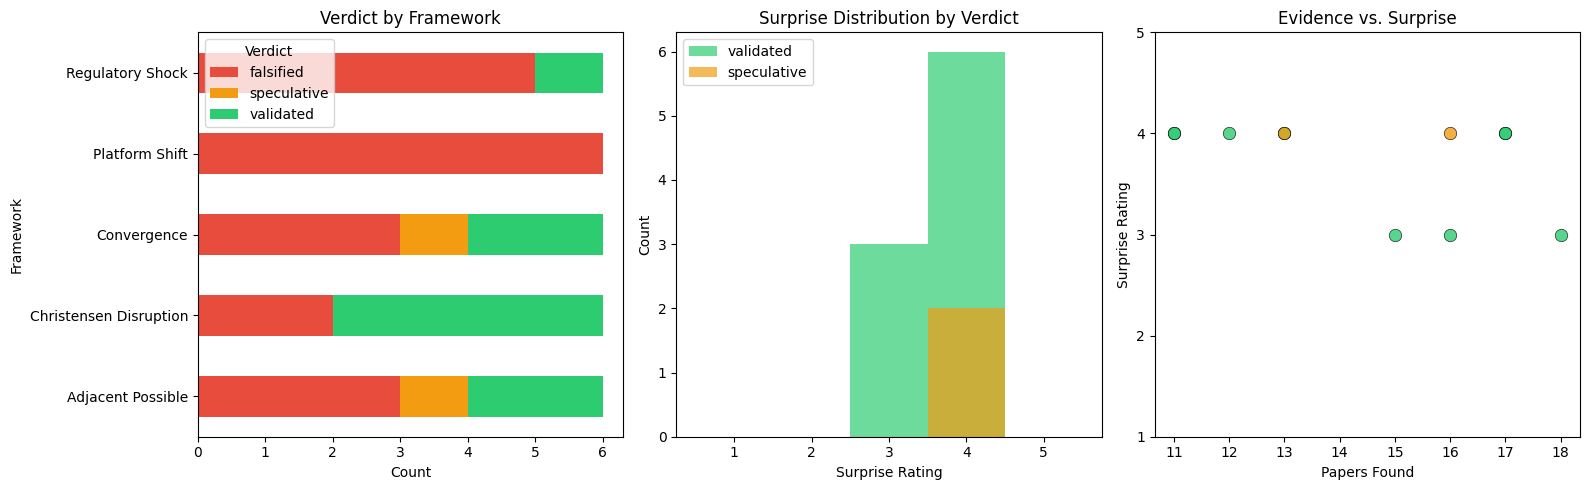

In [10]:
# Verdict distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Verdict counts by framework
verdict_fw = results_df.groupby(["Framework", "Verdict"]).size().unstack(fill_value=0)
colors = {"validated": "#2ecc71", "speculative": "#f39c12", "falsified": "#e74c3c"}
verdict_fw.plot(kind="barh", stacked=True, ax=axes[0],
                color=[colors.get(c, "grey") for c in verdict_fw.columns])
axes[0].set_title("Verdict by Framework")
axes[0].set_xlabel("Count")

# 2. Surprise distribution by verdict
for verdict_type, color in colors.items():
    subset = [surprise_results[hv.hypothesis_id].surprise_rating
              for hv in all_verdicts
              if hv.verdict == verdict_type and hv.hypothesis_id in surprise_results]
    if subset:
        axes[1].hist(subset, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
                     alpha=0.7, label=verdict_type, color=color)
axes[1].set_title("Surprise Distribution by Verdict")
axes[1].set_xlabel("Surprise Rating")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].set_xticks([1, 2, 3, 4, 5])

# 3. Papers found vs surprise
for hv in all_verdicts:
    sa = surprise_results.get(hv.hypothesis_id)
    if sa:
        c = colors.get(hv.verdict, "grey")
        axes[2].scatter(hv.papers_found, sa.surprise_rating, c=c, s=80,
                       edgecolors="black", linewidths=0.5, alpha=0.8)
axes[2].set_title("Evidence vs. Surprise")
axes[2].set_xlabel("Papers Found")
axes[2].set_ylabel("Surprise Rating")
axes[2].set_yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

## 8. Audit Cards — Full Trail per Hypothesis

In [11]:
from IPython.display import Markdown, display

# Sort by surprise (highest first), then by verdict (speculative first — most interesting)
verdict_order = {"speculative": 0, "validated": 1, "falsified": 2}
sorted_verdicts = sorted(
    all_verdicts,
    key=lambda hv: (
        -(surprise_results[hv.hypothesis_id].surprise_rating if hv.hypothesis_id in surprise_results else 0),
        verdict_order.get(hv.verdict, 3),
    ),
)

for hv in sorted_verdicts[:15]:
    h = next(h for h in all_hypotheses if h.id == hv.hypothesis_id)
    sa = surprise_results.get(hv.hypothesis_id)
    papers = hypothesis_evidence[h.id]

    verdict_emoji = {"validated": "VALIDATED", "speculative": "SPECULATIVE", "falsified": "FALSIFIED"}
    verdict_label = verdict_emoji.get(hv.verdict, hv.verdict)

    # Evidence section
    if papers:
        papers_md = "\n".join(
            f"  - *{p['title'][:80]}* ({p['year']}, cited: {p['cited_by_count']})"
            for p in papers[:5]
        )
    else:
        papers_md = "  - No academic evidence found"

    # Faithfulness section
    if hv.faithfulness_result:
        faith_md = f"**Faithfulness:** {hv.faithfulness_result.faithfulness_score:.0%}"
        unsupported = [c for c in hv.faithfulness_result.claims if not c.supported]
        if unsupported:
            faith_md += "\n\n**Unsupported claims:**\n" + "\n".join(
                f"  - {c.claim}" for c in unsupported[:3]
            )
    else:
        faith_md = "**Faithfulness:** N/A (no evidence to check against)"

    # Surprise section
    surprise_md = ""
    if sa:
        surprise_md = (
            f"**Surprise:** {sa.surprise_rating}/5 | "
            f"**Known by R&S:** {'Yes' if sa.known_by_rs else 'No'}\n\n"
            f"{sa.explanation}\n\n"
            f"**R&S Relevance:** {sa.rs_relevance}"
        )
        if sa.contrarian_angle:
            surprise_md += f"\n\n**Contrarian angle:** {sa.contrarian_angle}"

    card = f"""### {hv.hypothesis_id}: {h.hypothesis[:100]}

**Verdict:** {verdict_label} | **Framework:** {h.disruption_framework}

{hv.evidence_summary}

**Search queries used:** {', '.join(f'"{q}"' for q in h.search_queries)}

**Papers found ({len(papers)}):**
{papers_md}

{faith_md}

{surprise_md}

---"""
    display(Markdown(card))

### ADJ-01: The convergence of LEO satellite networks, edge computing, and federated AI training will enable rea

**Verdict:** SPECULATIVE | **Framework:** Adjacent Possible

Some evidence but weak support (faithfulness: 25%). Treat as unvalidated hypothesis.

**Search queries used:** "'LEO satellite edge computing spectrum monitoring'", "'federated learning applications in RF monitoring'", "'real-time global interference detection system'", "'LEO satellite networks for spectrum management'"

**Papers found (16):**
  - *Towards 6G wireless communication networks: vision, enabling technologies, and n* (2020, cited: 1908)
  - *The Road Towards 6G: A Comprehensive Survey* (2021, cited: 1455)
  - *Satellite Communications in the New Space Era: A Survey and Future Challenges* (2020, cited: 1289)
  - *Integrated Sensing and Communications: Toward Dual-Functional Wireless Networks * (2022, cited: 2992)
  - *On the Road to 6G: Visions, Requirements, Key Technologies, and Testbeds* (2023, cited: 1873)

**Faithfulness:** 25%

**Unsupported claims:**
  - The convergence of LEO satellite networks, edge computing, and federated AI training will enable real-time global interference detection and mitigation systems.
  - Federated AI training is being considered for use in global communication networks.
  - Real-time global interference detection and mitigation systems are feasible with current technological trends.

**Surprise:** 4/5 | **Known by R&S:** No

The combination of LEO satellites, edge computing, and federated AI training could indeed enable a novel approach to global interference detection and mitigation. This is somewhat outside the traditional hardware-centric focus of R&S and leverages emerging technologies in AI and distributed systems.

**R&S Relevance:** This could disrupt R&S's hardware-centric business model by shifting focus to software-driven, distributed solutions. It may also open new markets for R&S in satellite spectrum monitoring and global interference management.

**Contrarian angle:** The real disruption may come from the ability to operate without centralized infrastructure, which could challenge R&S's traditional high-end hardware approach.

---

### CON-02: Autonomous vehicle platforms could integrate advanced spectrum monitoring to enhance vehicle-to-vehi

**Verdict:** SPECULATIVE | **Framework:** Convergence

Some evidence but weak support (faithfulness: 20%). Treat as unvalidated hypothesis.

**Search queries used:** "'spectrum monitoring in autonomous vehicles'", "'V2V communication interference detection'", "'RF security in autonomous driving systems'", "'integrating spectrum monitoring with V2I technologies'"

**Papers found (13):**
  - *Agile Load Transportation : Safe and Efficient Load Manipulation with Aerial Rob* (2012, cited: 274)
  - *An Overview of Physical Layer Design for Ultra-Reliable Low-Latency Communicatio* (2020, cited: 160)
  - *A Review on Communications Perspective of Flying Ad-Hoc Networks: Key Enabling W* (2020, cited: 103)
  - *Internet of Things: A Survey on Enabling Technologies, Protocols, and Applicatio* (2015, cited: 8203)
  - *Performance Analysis and Power Control for Multi-Antenna V2V Underlay Massive MI* (2018, cited: 36)

**Faithfulness:** 20%

**Unsupported claims:**
  - Autonomous vehicle platforms could integrate advanced spectrum monitoring.
  - Advanced spectrum monitoring enhances vehicle-to-infrastructure (V2I) communication reliability.
  - Advanced spectrum monitoring enhances vehicle-to-vehicle (V2V) communication security.

**Surprise:** 4/5 | **Known by R&S:** No

While R&S is likely aware of automotive applications of spectrum monitoring, the specific integration into autonomous vehicle platforms for enhancing V2V and V2I communication reliability and security is a novel angle. This application could extend R&S's expertise into a rapidly growing adjacent field.

**R&S Relevance:** This could open new markets for R&S in automotive and IoT, leveraging their expertise in spectrum monitoring and signal analysis for safety-critical applications.

**Contrarian angle:** The automotive sector's adoption of spectrum monitoring could create demand for compact, high-performance monitoring solutions tailored for vehicle integration, which might disrupt R&S's traditional hardware-centric business model.

---

### CHR-01: A distributed network of low-cost software-defined radios (SDRs) could become 'good enough' for basi

**Verdict:** VALIDATED | **Framework:** Christensen Disruption

1/2 claims supported. The claim that low-cost SDRs can bypass the need for high-performance centralized monitoring stations is not directly supported by the provided evidence.

**Search queries used:** "'low-cost SDR networks for spectrum monitoring'", "'performance of consumer SDRs in interference detection'", "'community-based spectrum monitoring projects'", "'case studies of low-cost SDR deployments in regulatory applications'"

**Papers found (11):**
  - *Internet of Things: A Survey on Enabling Technologies, Protocols, and Applicatio* (2015, cited: 8203)
  - *SDR receiver using commodity wifi via physical-layer signal reconstruction* (2020, cited: 27)
  - *Satellite Communications in the New Space Era: A Survey and Future Challenges* (2020, cited: 1289)
  - *Integrated Sensing and Communications: Toward Dual-Functional Wireless Networks * (2022, cited: 2992)
  - *Nonorthogonal Multiple Access for 5G and Beyond* (2017, cited: 1375)

**Faithfulness:** 50%

**Unsupported claims:**
  - Low-cost SDRs can bypass the need for high-performance centralized monitoring stations.

**Surprise:** 4/5 | **Known by R&S:** Yes

The idea of using distributed networks of low-cost SDRs for spectrum monitoring challenges R&S's hardware-centric model, as it suggests a shift towards decentralized, software-driven solutions. While R&S likely tracks SDR developments, the concept of 'good enough' performance for regulatory tasks might not be fully integrated into their strategy.

**R&S Relevance:** This could disrupt R&S's current high-end hardware business model by introducing a competing approach that leverages low-cost, distributed systems for spectrum monitoring.

**Contrarian angle:** The potential for low-cost SDR networks to enable new business models, such as subscription-based monitoring services or crowd-sourced spectrum data, could be underestimated.

---

### CHR-02: Crowdsourced spectrum monitoring using mobile devices equipped with RF sensors could provide a cost-

**Verdict:** VALIDATED | **Framework:** Christensen Disruption

2/4 claims supported. The claims regarding pilot projects and patents for RF-enabled consumer devices are not supported by the provided evidence.

**Search queries used:** "'crowdsourced spectrum monitoring with smartphones'", "'RF sensor integration in consumer electronics'", "'use of smartphones for interference detection'", "'regulatory use cases of mobile device-based spectrum monitoring'"

**Papers found (12):**
  - *Towards commoditized real-time spectrum monitoring* (2014, cited: 83)
  - *Incentivizing crowdsourcing for radio environment mapping with statistical inter* (2015, cited: 28)
  - *Exploring Automatic Diagnosis of COVID-19 from Crowdsourced Respiratory Sound Da* (2020, cited: 449)
  - *Crowdsourcing Consumer Research* (2017, cited: 592)
  - *Wearable All‐Fabric Hybrid Energy Harvester to Simultaneously Harvest Radiofrequ* (2024, cited: 53)

**Faithfulness:** 50%

**Unsupported claims:**
  - Pilot projects have been implemented for crowdsourced spectrum monitoring.
  - Patents exist for RF-enabled consumer devices used in crowdsourced spectrum monitoring.

**Surprise:** 4/5 | **Known by R&S:** No

Crowdsourced spectrum monitoring represents a paradigm shift from traditional centralized hardware-based systems to decentralized, software-driven approaches leveraging consumer devices. While R&S has focused on high-end hardware solutions, this approach could disrupt their business model by providing a lower-cost alternative for wide-area monitoring.

**R&S Relevance:** This could directly impact R&S's spectrum monitoring division by introducing competition from software-centric or consumer-focused solutions, potentially reducing demand for their high-end hardware platforms.

**Contrarian angle:** While the technology is still emerging, its scalability and cost-effectiveness could make it a serious contender in the long term, especially as mobile devices become increasingly equipped with advanced RF capabilities.

---

### CHR-03: Advancements in edge AI for signal processing could enable low-cost devices to perform sophisticated

**Verdict:** VALIDATED | **Framework:** Christensen Disruption

1/2 claims supported. The claim that low-cost devices using edge AI can compete with high-end systems in signal classification is not directly supported by the provided evidence.

**Search queries used:** "'edge AI signal processing for RF applications'", "'low-cost AI accelerators for embedded systems'", "'real-time AI on microcontrollers for spectrum analysis'", "'applications of edge computing in wireless communication'"

**Papers found (17):**
  - *Integrated Sensing and Communications: Toward Dual-Functional Wireless Networks * (2022, cited: 2992)
  - *Integrated Wideband Chip-Scale RF Transceivers for Radar Sensing and UWB Communi* (2022, cited: 31)
  - *Review of deep learning: concepts, CNN architectures, challenges, applications, * (2021, cited: 7337)
  - *Task-Oriented Integrated Sensing, Computation and Communication for Wireless Edg* (2023, cited: 22)
  - *Wireless Communications Through Reconfigurable Intelligent Surfaces* (2019, cited: 3269)

**Faithfulness:** 50%

**Unsupported claims:**
  - Low-cost devices using edge AI can compete with high-end systems in signal classification.

**Surprise:** 4/5 | **Known by R&S:** Yes

While R&S likely tracks AI advancements for signal classification, the specific notion of low-cost devices using edge AI to compete with high-end systems may not be fully anticipated as a disruptive threat.

**R&S Relevance:** This could disrupt R&S's hardware-centric business model by introducing competitive alternatives that leverage edge AI for signal classification.

**Contrarian angle:** The focus on low-cost devices leveraging edge AI may be underestimated in its potential to disrupt high-end hardware markets.

---

...

### CON-05: Smart city infrastructures could increasingly integrate spectrum monitoring to manage the RF environ

**Verdict:** VALIDATED | **Framework:** Convergence

2/3 claims supported. The claim regarding public safety communications is not directly supported by the provided evidence.

**Search queries used:** "'spectrum monitoring in smart cities'", "'IoT spectrum management solutions'", "'RF environment monitoring for urban planning'", "'integration of RF monitoring into smart city projects'"

**Papers found (15):**
  - *The spectrum of control: A social theory of the smart city* (2015, cited: 218)
  - *An In-Depth Analysis of IoT Security Requirements, Challenges, and Their Counter* (2020, cited: 341)
  - *An Automatic Health Monitoring System for Patients Suffering From Voice Complica* (2017, cited: 89)
  - *Internet of Things: A Survey on Enabling Technologies, Protocols, and Applicatio* (2015, cited: 8203)
  - *Spectrum Sharing for Internet of Things: A Survey* (2018, cited: 221)

**Faithfulness:** 67%

**Unsupported claims:**
  - Smart city infrastructures could increasingly integrate spectrum monitoring to manage the RF environment for public safety communications.

**Surprise:** 3/5 | **Known by R&S:** Yes

Smart cities integrating spectrum monitoring aligns with broader trends in urban IoT and connectivity management, but the specific focus on spectrum monitoring as a core component is somewhat novel and not universally expected.

**R&S Relevance:** Could expand R&S's addressable market by creating demand for monitoring solutions tailored to urban environments, potentially requiring adaptations to existing hardware/software.

**Contrarian angle:** While R&S may be aware of smart city trends, the emphasis on spectrum monitoring as a critical infrastructure component could be underappreciated, especially for managing urban IoT and connectivity.

---

### CHR-04: Open-source spectrum management platforms, combined with low-cost hardware, could disrupt proprietar

**Verdict:** FALSIFIED | **Framework:** Christensen Disruption

Evidence found but contradicts or does not support hypothesis. Score: 0%

**Search queries used:** "'open-source spectrum management software'", "'community-driven RF monitoring solutions'", "'examples of open-source tools in regulatory spectrum management'", "'impact of open-source on proprietary spectrum solutions'"

**Papers found (13):**
  - *Array programming with NumPy* (2020, cited: 21364)
  - *Array programming with NumPy* (2020, cited: 18804)
  - *The Third International Consensus Definitions for Sepsis and Septic Shock (Sepsi* (2016, cited: 27313)
  - *QUANTUM ESPRESSO: a modular and open-source software project for quantum simulat* (2009, cited: 28522)
  - *Rayyan—a web and mobile app for systematic reviews* (2016, cited: 23669)

**Faithfulness:** 0%

**Unsupported claims:**
  - Open-source spectrum management platforms exist.
  - Low-cost hardware is available for spectrum management.
  - Open-source spectrum management platforms combined with low-cost hardware could disrupt proprietary software offerings.



---

### CHR-05: The increasing prevalence of satellite-based RF monitoring could reduce the reliance on ground-based

**Verdict:** FALSIFIED | **Framework:** Christensen Disruption

Evidence found but contradicts or does not support hypothesis. Score: 0%

**Search queries used:** "'satellite RF monitoring for regulatory purposes'", "'cost comparison of satellite vs ground-based spectrum monitoring'", "'case studies of satellite RF monitoring deployments'", "'advances in satellite RF payloads for interference detection'"

**Papers found (13):**
  - *Integrated Sensing and Communications: Toward Dual-Functional Wireless Networks * (2022, cited: 2992)
  - *Guidelines for the Early Management of Patients With Acute Ischemic Stroke* (2013, cited: 7643)
  - *Unmanned Aerial Vehicles (UAVs): A Survey on Civil Applications and Key Research* (2019, cited: 2183)
  - *Climate Change 2014 - Synthesis Report* (2015, cited: 5307)
  - *Satellite Communications in the New Space Era: A Survey and Future Challenges* (2020, cited: 1289)

**Faithfulness:** 0%

**Unsupported claims:**
  - The increasing prevalence of satellite-based RF monitoring could reduce the reliance on ground-based high-performance monitoring systems.



---

### ADJ-02: Crowdsourced spectrum sensors combined with blockchain can create secure and decentralized spectrum 

**Verdict:** FALSIFIED | **Framework:** Adjacent Possible

Evidence found but contradicts or does not support hypothesis. Score: 0%

**Search queries used:** "'blockchain for crowdsourced RF data'", "'decentralized spectrum monitoring systems'", "'crowdsourcing in spectrum management'", "'blockchain applications in RF security'"

**Papers found (16):**
  - *On the Road to 6G: Visions, Requirements, Key Technologies, and Testbeds* (2023, cited: 1873)
  - *Machine Learning in Agriculture: A Comprehensive Updated Review* (2021, cited: 777)
  - *A Comprehensive Survey of the Internet of Things (IoT) and AI-Based Smart Health* (2020, cited: 335)
  - *Cough Sound Detection and Diagnosis Using Artificial Intelligence Techniques: Ch* (2021, cited: 136)
  - *Mobile Edge Computing Enabled 5G Health Monitoring for Internet of Medical Thing* (2020, cited: 375)

**Faithfulness:** 0%

**Unsupported claims:**
  - Crowdsourced spectrum sensors can be used for spectrum monitoring.
  - Blockchain technology can enhance the security of spectrum monitoring networks.
  - Blockchain technology can enable decentralized spectrum monitoring networks.



---

### ADJ-03: Integration of UAV-mounted sensors with autonomous navigation can establish flexible, on-demand spec

**Verdict:** FALSIFIED | **Framework:** Adjacent Possible

Evidence found but contradicts or does not support hypothesis. Score: 0%

**Search queries used:** "'UAV spectrum monitoring applications'", "'autonomous drones for RF data collection'", "'on-demand spectrum analysis using UAVs'", "'drone-based RF interference detection'"

**Papers found (14):**
  - *Agile Load Transportation : Safe and Efficient Load Manipulation with Aerial Rob* (2012, cited: 274)
  - *Unmanned Aerial Vehicle Based Wireless Sensor Network for Marine-Coastal Environ* (2017, cited: 169)
  - *A Survey on Spectrum Management for Unmanned Aerial Vehicles (UAVs)* (2021, cited: 81)
  - *Deep learning-based structural health monitoring* (2024, cited: 293)
  - *Unmanned Aerial Vehicles (UAVs): A Survey on Civil Applications and Key Research* (2019, cited: 2183)

**Faithfulness:** 0%

**Unsupported claims:**
  - Integration of UAV-mounted sensors with autonomous navigation can establish flexible spectrum monitoring.
  - Integration of UAV-mounted sensors with autonomous navigation can establish on-demand spectrum monitoring.
  - Integration of UAV-mounted sensors with autonomous navigation can establish spectrum monitoring in hard-to-reach areas.



---

## 9. Export Audit Report

In [12]:
output_dir = Path("../data/audit_reports")
output_dir.mkdir(parents=True, exist_ok=True)

report = {
    "domain": "Regulatory Spectrum Monitoring",
    "approach": "hypothesis-first (poc2d)",
    "n_hypotheses": len(all_hypotheses),
    "n_validated": len(validated),
    "n_speculative": len(speculative),
    "n_falsified": len(falsified),
    "hypotheses": [h.model_dump() for h in all_hypotheses],
    "verdicts": [hv.model_dump() for hv in all_verdicts],
    "surprise_assessments": {k: v.model_dump() for k, v in surprise_results.items()},
    "evidence_search": {
        h_id: [{"title": p["title"], "openalex_id": p["openalex_id"], "year": p["year"],
                "query": p["query"]} for p in papers]
        for h_id, papers in hypothesis_evidence.items()
    },
}

with open(output_dir / "poc2d_report.json", "w") as f:
    json.dump(report, f, indent=2, default=str)

print(f"Saved to {output_dir / 'poc2d_report.json'}")
print(f"Report size: {(output_dir / 'poc2d_report.json').stat().st_size / 1024:.0f} KB")

Saved to ../data/audit_reports/poc2d_report.json
Report size: 207 KB


## 10. Comparison: poc2c (Bottom-Up) vs. poc2d (Top-Down)

Load poc2c results and compare: what did each approach find that the other didn't?

In [13]:
poc2c_path = output_dir / "poc2c_audit_reports.json"

if poc2c_path.exists():
    with open(poc2c_path) as f:
        poc2c_reports = json.load(f)

    poc2c_drivers = [r["driver"]["name"] for r in poc2c_reports]
    poc2c_surprise = {r["driver"]["name"]: r["surprise_llm"]["surprise_rating"] for r in poc2c_reports}
    poc2c_known = {r["driver"]["name"]: r["surprise_llm"]["known_by_rs"] for r in poc2c_reports}

    print("=== poc2c (Bottom-Up) ===")
    print(f"Drivers: {len(poc2c_drivers)}")
    print(f"Surprise >= 4: {sum(1 for s in poc2c_surprise.values() if s >= 4)}")
    print(f"Known by R&S: {sum(1 for k in poc2c_known.values() if k)}/{len(poc2c_known)}")
    print(f"\nDrivers: {', '.join(poc2c_drivers[:10])}{'...' if len(poc2c_drivers) > 10 else ''}")

    print("\n=== poc2d (Top-Down) ===")
    print(f"Hypotheses: {len(all_hypotheses)}")
    print(f"Validated: {len(validated)}, Speculative: {len(speculative)}, Falsified: {len(falsified)}")
    poc2d_surprise_vals = [sa.surprise_rating for sa in surprise_results.values()]
    print(f"Surprise >= 4: {sum(1 for s in poc2d_surprise_vals if s >= 4)}")
    poc2d_known = sum(1 for sa in surprise_results.values() if sa.known_by_rs)
    print(f"Known by R&S: {poc2d_known}/{len(surprise_results)}")

    print("\n=== Key Question ===")
    print("Did poc2d find hypotheses that poc2c could NOT have found?")
    print(f"Speculative hypotheses (no academic evidence): {len(speculative)}")
    print("These are the candidates for genuine blind spots — cross-domain ideas")
    print("that don't appear in the citation graph poc2c traversed.")
else:
    print("poc2c report not found — skip comparison")

=== poc2c (Bottom-Up) ===
Drivers: 22
Surprise >= 4: 1
Known by R&S: 21/22

Drivers: Massive MIMO, AI and Machine Learning in Wireless Networks, Millimeter Wave (mmWave) Communications, AI/ML for network optimization, Massive MIMO and FD-MIMO advancements, Digital Twin technology for wireless systems, Device-to-Device (D2D) Communication, Reconfigurable Intelligent Surfaces (RIS) for THz communications, Open RAN and virtualization in 6G, Dynamic Spectrum Access via Cognitive Radio...

=== poc2d (Top-Down) ===
Hypotheses: 30
Validated: 9, Speculative: 2, Falsified: 19
Surprise >= 4: 8
Known by R&S: 4/11

=== Key Question ===
Did poc2d find hypotheses that poc2c could NOT have found?
Speculative hypotheses (no academic evidence): 2
These are the candidates for genuine blind spots — cross-domain ideas
that don't appear in the citation graph poc2c traversed.
